# Casting Defect Detection with OpenCV

Goal:
Detect possible defects in casting images using classical image processing.

Pipeline:

Image → Grayscale → CLAHE → Blur → Thresholding →
Morphology → Canny → Contours → Bounding Boxes →
Good / Defective Decision

Import libraries

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

Download Dataset: Casting defect = a crack, hole, spot, or other defect in the manufactured metal part.

In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "ravirajsinh45/real-life-industrial-dataset-of-casting-product"
)

print("Dataset path:", path)

Using Colab cache for faster access to the 'real-life-industrial-dataset-of-casting-product' dataset.
Dataset path: /kaggle/input/real-life-industrial-dataset-of-casting-product


Dataset Paths

In [ ]:
train_good = os.path.join(
    path, "casting_data/casting_data/train/ok_front"
)

train_def = os.path.join(
    path, "casting_data/casting_data/train/def_front"
)

test_good = os.path.join(
    path, "casting_data/casting_data/test/ok_front"
)

test_def = os.path.join(
    path, "casting_data/casting_data/test/def_front"
)

print("Train Good:", len(os.listdir(train_good)))
print("Train Defective:", len(os.listdir(train_def)))

print("Test Good:", len(os.listdir(test_good)))
print("Test Defective:", len(os.listdir(test_def)))

Train Good: 2875
Train Defective: 3758
Test Good: 262
Test Defective: 453


Explore Images

Load one Good and one Defective image

In [ ]:
good_file = "cast_ok_0_3766.jpeg"
def_file = "cast_def_0_6388.jpeg"

good_path = os.path.join(train_good, good_file)
def_path = os.path.join(train_def, def_file)

good_img = cv2.imread(good_path)
def_img = cv2.imread(def_path)

print("Good:", good_file)
print("Defective:", def_file)

Good: cast_ok_0_3766.jpeg
Defective: cast_def_0_6388.jpeg


Show Good vs Defective

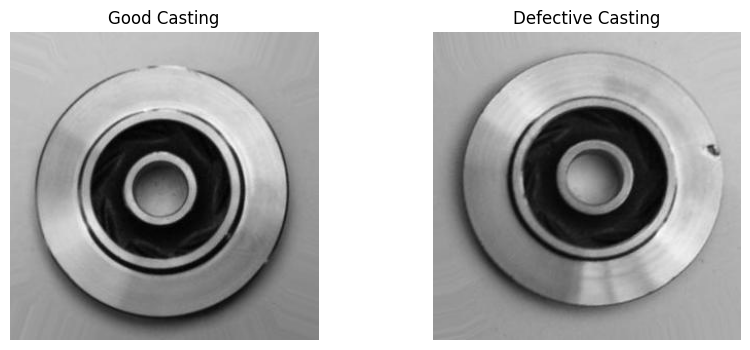

In [ ]:
good_rgb = cv2.cvtColor(good_img, cv2.COLOR_BGR2RGB)
def_rgb = cv2.cvtColor(def_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(good_rgb)
plt.title("Good Casting")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(def_rgb)
plt.title("Defective Casting")
plt.axis("off")

plt.show()

Grayscale

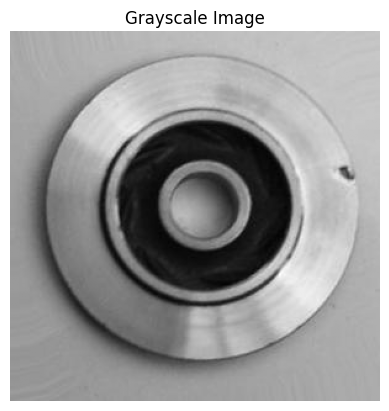

In [ ]:
gray = cv2.cvtColor(def_img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

CLAHE

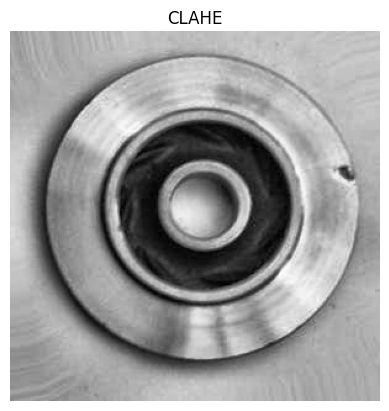

In [ ]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

enhanced = clahe.apply(gray)

plt.imshow(enhanced, cmap="gray")
plt.title("CLAHE")
plt.axis("off")
plt.show()

Gaussian Blur

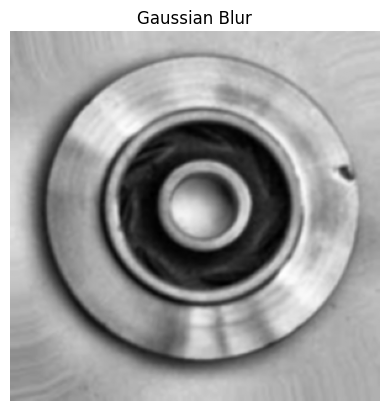

In [ ]:
gaussian = cv2.GaussianBlur(
    enhanced,
    (5, 5),
    0
)

plt.imshow(gaussian, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")
plt.show()

Median Blur

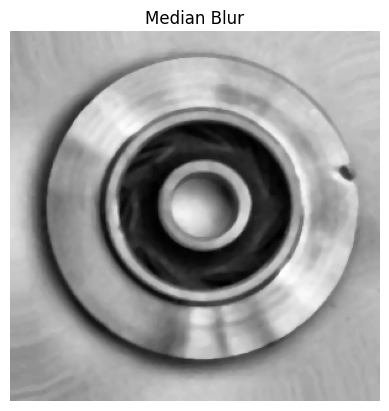

In [ ]:
median = cv2.medianBlur(
    enhanced,
    5
)

plt.imshow(median, cmap="gray")
plt.title("Median Blur")
plt.axis("off")
plt.show()

Gaussian → smooth general noise
Median → good for salt-and-pepper noise

### Black Hat Morphology

Black Hat highlights small dark regions on a bright background.
This can help reveal dark casting defects.

Black Hat Morphology highlights small dark regions on a bright background.

Formula:

Black Hat = Closing - Original Image

It is useful for detecting dark defects, spots, or cracks.

In the output:
bright/white areas = dark regions detected in the original image.

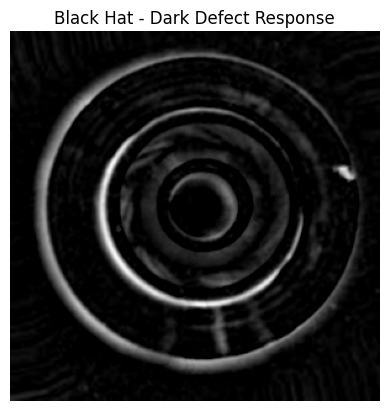

In [ ]:
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (15, 15)
)

blackhat = cv2.morphologyEx(
    gaussian,
    cv2.MORPH_BLACKHAT,
    kernel
)

plt.imshow(blackhat, cmap="gray")
plt.title("Black Hat - Dark Defect Response")
plt.axis("off")
plt.show()

Create a circular ROI

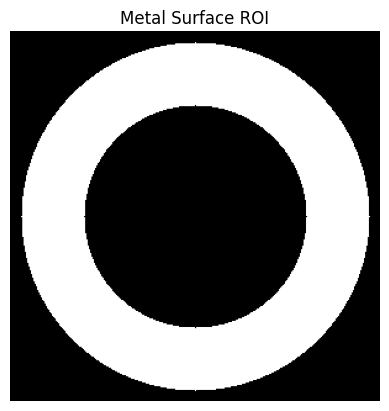

In [ ]:
h, w = gray.shape
center = (w // 2, h // 2)

inner_radius = int(min(h, w) * 0.30)
outer_radius = int(min(h, w) * 0.47)

roi_mask = np.zeros_like(gray)

# Outer circle
cv2.circle(roi_mask, center, outer_radius, 255, -1)

# Remove inner circle
cv2.circle(roi_mask, center, inner_radius, 0, -1)

plt.imshow(roi_mask, cmap="gray")
plt.title("Metal Surface ROI")
plt.axis("off")
plt.show()

Black Hat only inside ROI

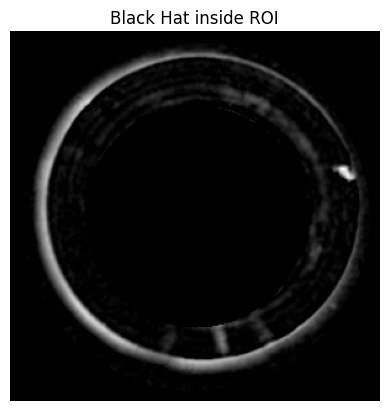

In [ ]:
roi_blackhat = cv2.bitwise_and(
    blackhat,
    blackhat,
    mask=roi_mask
)

plt.imshow(roi_blackhat, cmap="gray")
plt.title("Black Hat inside ROI")
plt.axis("off")
plt.show()

Otsu Threshold

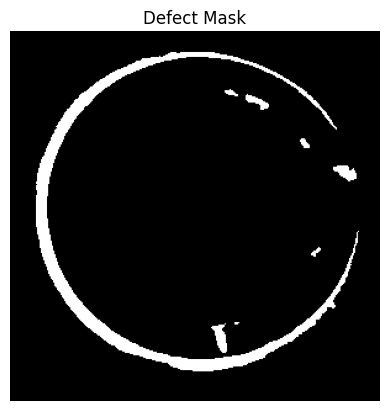

In [ ]:
_, binary = cv2.threshold(
    roi_blackhat,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.imshow(binary, cmap="gray")
plt.title("Defect Mask")
plt.axis("off")
plt.show()

Opening to remove small noise

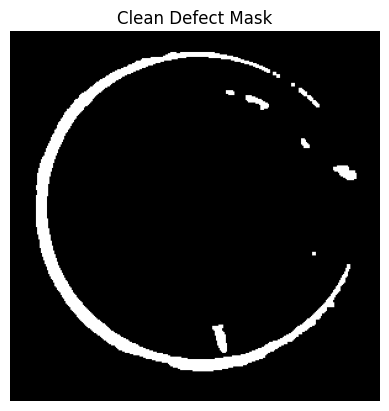

In [ ]:
kernel_small = np.ones((3, 3), np.uint8)

clean = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel_small
)

plt.imshow(clean, cmap="gray")
plt.title("Clean Defect Mask")
plt.axis("off")
plt.show()

Contours

In [ ]:
contours, _ = cv2.findContours(
    clean,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Contours:", len(contours))

Contours: 10


Keep only small defects

In [ ]:
defect_contours = []

for c in contours:
    area = cv2.contourArea(c)
    x, y, w, h = cv2.boundingRect(c)

    if 20 < area < 500 and w < 50 and h < 50:
        defect_contours.append(c)

print("Possible defects:", len(defect_contours))

Possible defects: 5


Print the feature of each contour

In [ ]:

for i, c in enumerate(contours):
    area = cv2.contourArea(c)
    x, y, w, h = cv2.boundingRect(c)
    peri = cv2.arcLength(c, True)

    if peri == 0:
        continue

    circularity = 4 * np.pi * area / (peri * peri)
    aspect_ratio = w / float(h)

    print(
        f"Contour {i}: area={area:.1f}, w={w}, h={h}, "
        f"aspect_ratio={aspect_ratio:.2f}, circularity={circularity:.2f}"
    )

Contour 0: area=137.5, w=12, h=23, aspect_ratio=0.52, circularity=0.49
Contour 1: area=4.0, w=3, h=3, aspect_ratio=1.00, circularity=0.79
Contour 2: area=122.0, w=19, h=12, aspect_ratio=1.58, circularity=0.59
Contour 3: area=27.0, w=7, h=8, aspect_ratio=0.88, circularity=0.67
Contour 4: area=81.0, w=19, h=12, aspect_ratio=1.58, circularity=0.41
Contour 5: area=16.0, w=7, h=4, aspect_ratio=1.75, circularity=0.71
Contour 6: area=51.0, w=17, h=16, aspect_ratio=1.06, circularity=0.25
Contour 7: area=4.0, w=3, h=3, aspect_ratio=1.00, circularity=0.79
Contour 8: area=9.0, w=6, h=5, aspect_ratio=1.20, circularity=0.40
Contour 9: area=4236.5, w=255, h=259, aspect_ratio=0.98, circularity=0.03


show the contour numbers on the image.

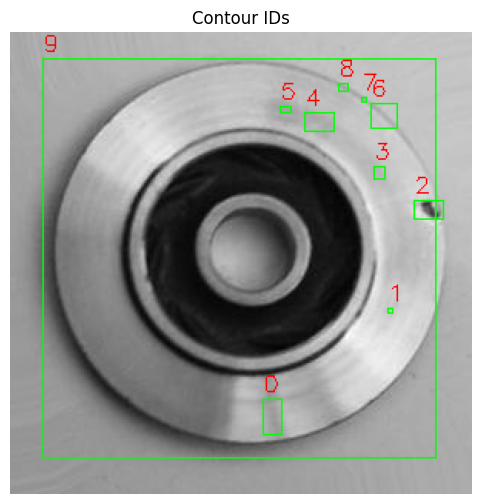

In [ ]:
label_img = def_img.copy()

for i, c in enumerate(contours):
    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(label_img, (x, y), (x+w, y+h), (0, 255, 0), 1)
    cv2.putText(
        label_img,
        str(i),
        (x, y-5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 0, 255),
        1
    )

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(label_img, cv2.COLOR_BGR2RGB))
plt.title("Contour IDs")
plt.axis("off")
plt.show()

In [ ]:
candidates = []

for i, c in enumerate(contours):

    area = cv2.contourArea(c)
    x, y, w, h = cv2.boundingRect(c)

    # remove tiny regions and huge ROI boundary
    if 20 < area < 500 and w < 50 and h < 50:

        mask = np.zeros_like(roi_blackhat)
        cv2.drawContours(mask, [c], -1, 255, -1)

        mean_response = cv2.mean(
            roi_blackhat,
            mask=mask
        )[0]

        candidates.append((i, c, mean_response))

        print(
            f"Contour {i}: "
            f"area={area:.1f}, "
            f"blackhat={mean_response:.1f}"
        )

Contour 0: area=137.5, blackhat=45.3
Contour 2: area=122.0, blackhat=75.8
Contour 3: area=27.0, blackhat=32.9
Contour 4: area=81.0, blackhat=35.5
Contour 6: area=51.0, blackhat=42.2


Then keep only the right candidates.

In [ ]:
best = max(candidates, key=lambda x: x[2])

best_id, best_contour, score = best

print("Best contour:", best_id)
print("Score:", score)

Best contour: 2
Score: 75.76712328767123


Final Result

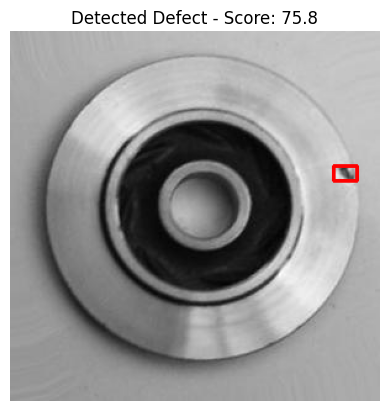

In [ ]:
result = def_img.copy()

x, y, w, h = cv2.boundingRect(best_contour)

cv2.rectangle(
    result,
    (x, y),
    (x + w, y + h),
    (0, 0, 255),
    2
)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Defect - Score: {score:.1f}")
plt.axis("off")
plt.show()

pipeline view

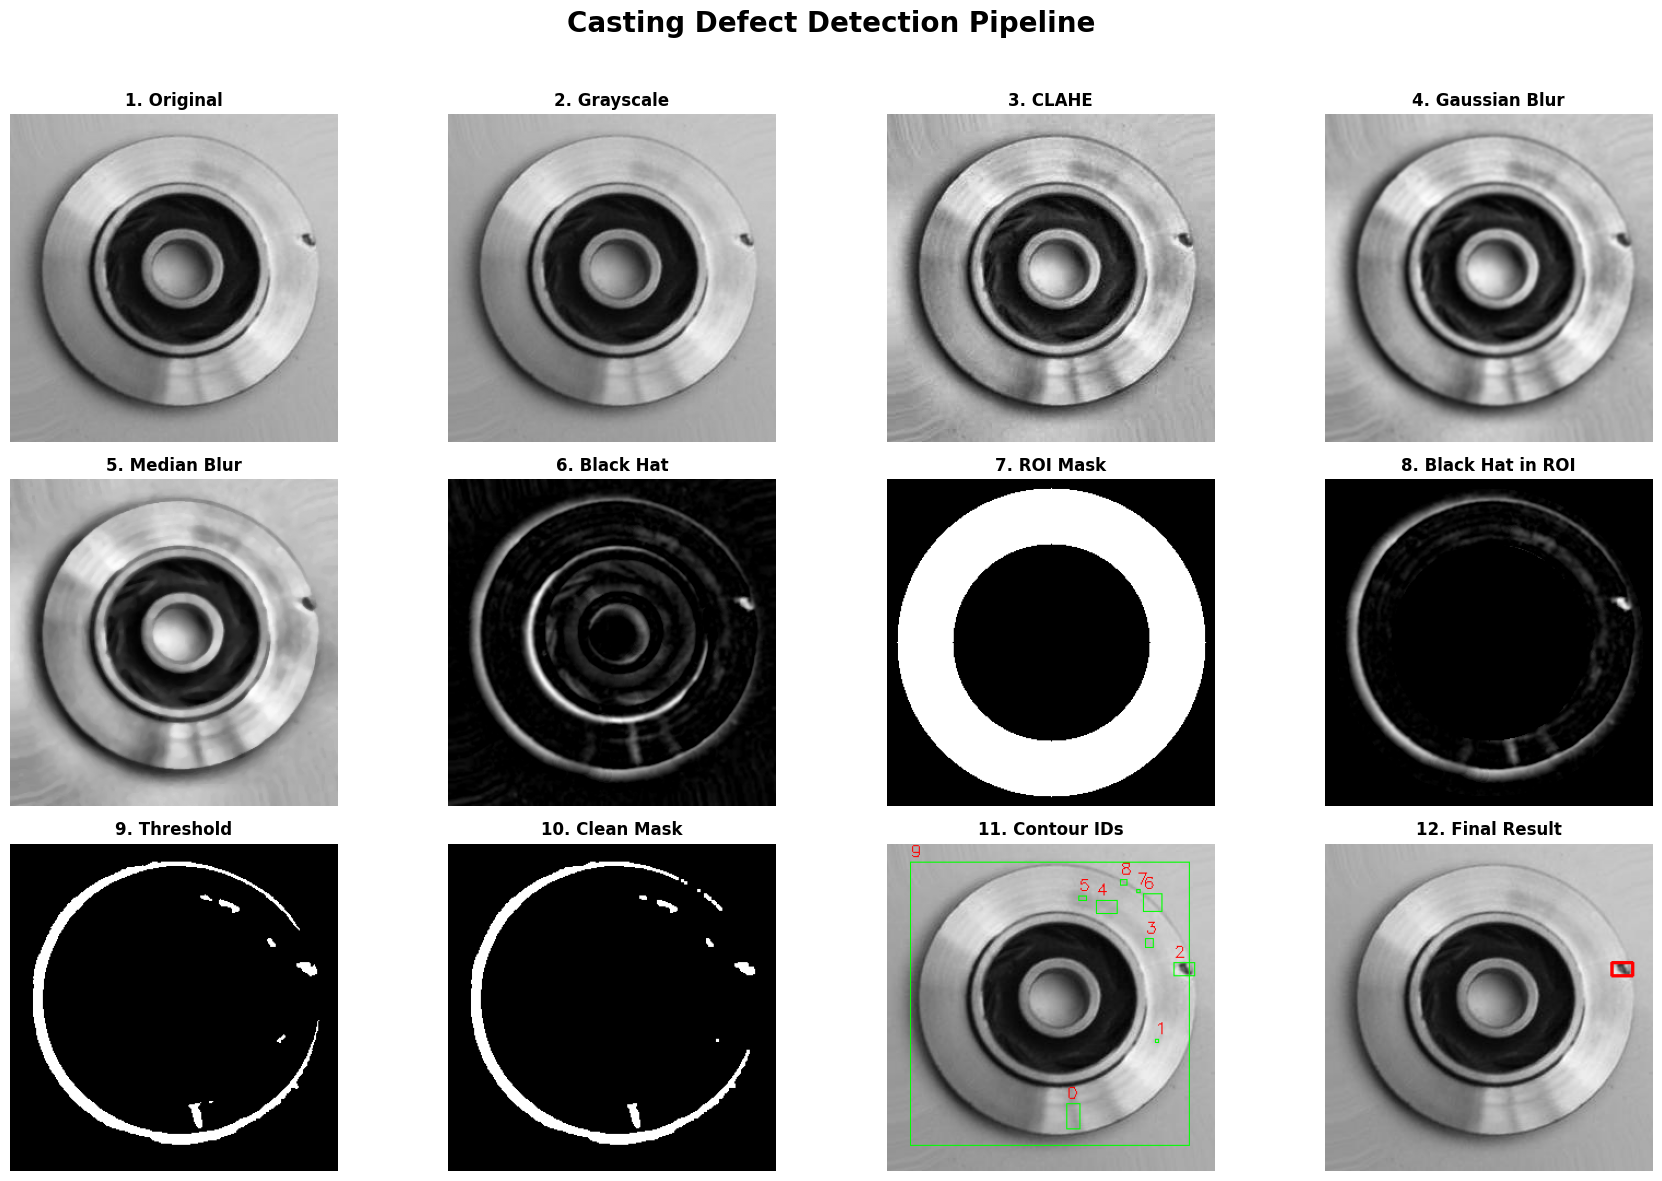

In [ ]:
import matplotlib.pyplot as plt
import cv2

# Convert BGR images to RGB if needed
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
label_img_rgb = cv2.cvtColor(label_img, cv2.COLOR_BGR2RGB)

# If def_rgb is not already defined, uncomment this:
# def_rgb = cv2.cvtColor(def_img, cv2.COLOR_BGR2RGB)

steps = [
    ("1. Original", def_rgb),
    ("2. Grayscale", gray),
    ("3. CLAHE", enhanced),
    ("4. Gaussian Blur", gaussian),

    ("5. Median Blur", median),
    ("6. Black Hat", blackhat),
    ("7. ROI Mask", roi_mask),
    ("8. Black Hat in ROI", roi_blackhat),

    ("9. Threshold", binary),
    ("10. Clean Mask", clean),
    ("11. Contour IDs", label_img_rgb),
    ("12. Final Result", result_rgb)
]

cols = 4
rows = (len(steps) + cols - 1) // cols

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Casting Defect Detection Pipeline", fontsize=20, fontweight="bold")

for i, (title, img) in enumerate(steps, 1):
    ax = plt.subplot(rows, cols, i)

    if len(img.shape) == 2:
        ax.imshow(img, cmap="gray")
    else:
        ax.imshow(img)

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Color Image Experiment

Practice BGR, RGB, Grayscale, HSV, HSV channels, and color masking.

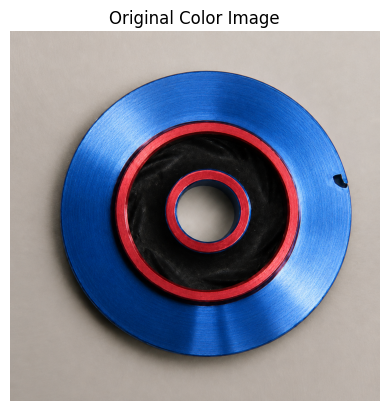

In [ ]:
color_img = cv2.imread("/content/22.png")

color_rgb = cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB)

plt.imshow(color_rgb)
plt.title("Original Color Image")
plt.axis("off")
plt.show()

BGR → RGB / Gray / HSV


### RGB, Grayscale, and HSV Comparison

- **RGB:** Shows the original color image.
- **Grayscale:** Keeps only brightness/intensity information.
- **Hue (H):** Represents the type of color.
- **Saturation (S):** Represents how strong or pure the color is.
- **Value (V):** Represents the brightness of the image.



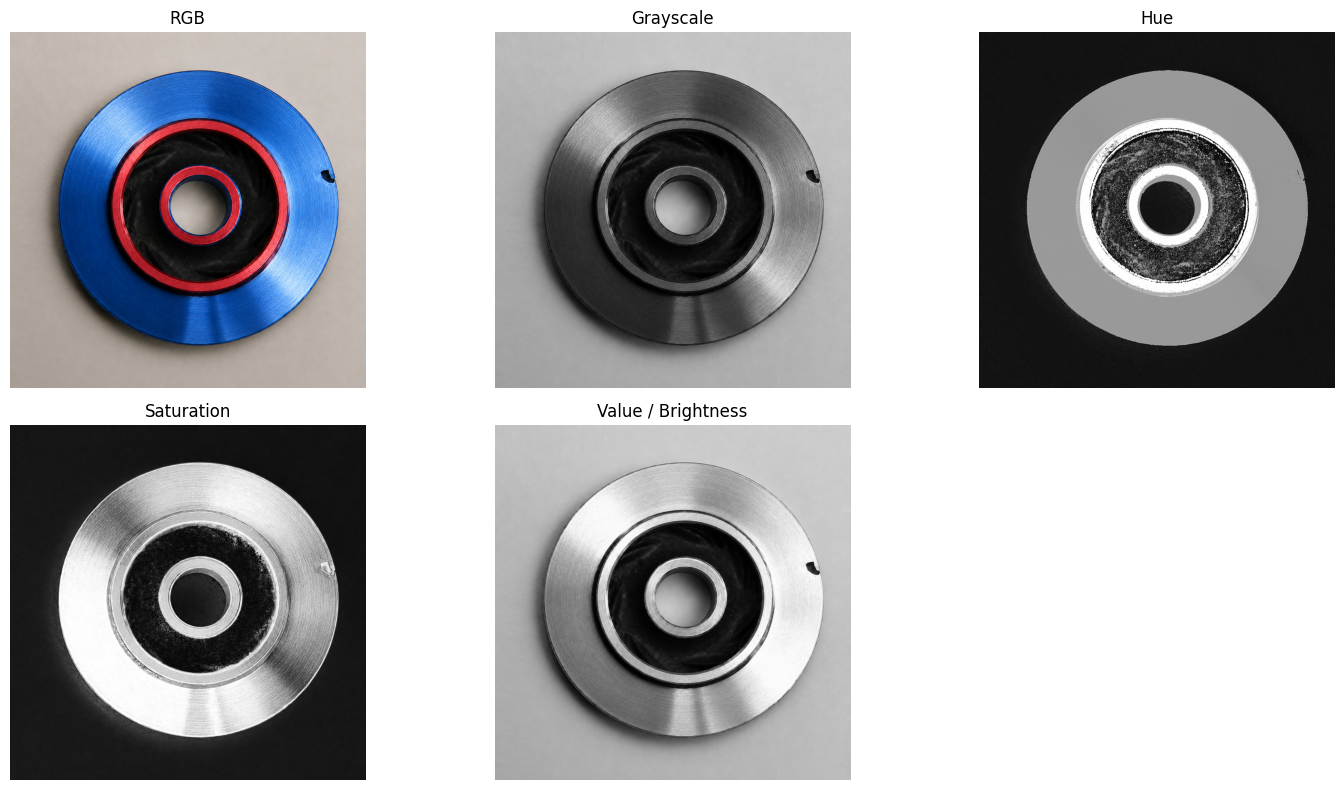

In [ ]:
gray_color = cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(color_img, cv2.COLOR_BGR2HSV)

h, s, v = cv2.split(hsv)

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(color_rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(gray_color, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(h, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(s, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(v, cmap="gray")
plt.title("Value / Brightness")
plt.axis("off")

plt.tight_layout()
plt.show()

Color Detection with cv2.inRange()

### HSV Color Detection

HSV makes color segmentation easier because color information is separated from brightness.

- `cv2.inRange()` creates a binary mask for a selected color range.
- White pixels in the mask represent detected colors.
- `cv2.bitwise_and()` keeps only the detected color regions from the original image.

In this example, blue and red regions were successfully separated using HSV.

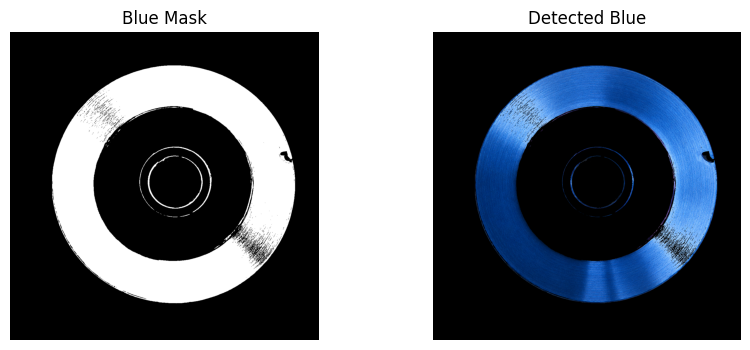

In [ ]:
lower_blue = np.array([90, 80, 50])
upper_blue = np.array([140, 255, 255])

blue_mask = cv2.inRange(
    hsv,
    lower_blue,
    upper_blue
)

blue_result = cv2.bitwise_and(
    color_img,
    color_img,
    mask=blue_mask
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(blue_mask, cmap="gray")
plt.title("Blue Mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(blue_result, cv2.COLOR_BGR2RGB))
plt.title("Detected Blue")
plt.axis("off")

plt.show()

Imagine you tell the computer:

“Find every blue part of the image. Mark those parts white, and make everything else black.”

That creates the Blue Mask:

White = this pixel is blue ✅
Black = this pixel is not blue ❌

Then bitwise_and() tells the computer:

“Now keep only the parts of the original image where the mask is white.”

So:

Original image → Blue mask → Keep blue regions only.

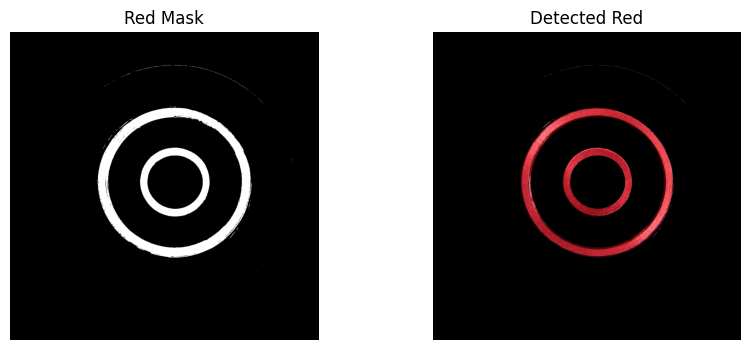

In [ ]:
lower_red1 = np.array([0, 80, 50])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 80, 50])
upper_red2 = np.array([179, 255, 255])

mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)

red_mask = mask1 | mask2

red_result = cv2.bitwise_and(
    color_img,
    color_img,
    mask=red_mask
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(red_mask, cmap="gray")
plt.title("Red Mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(red_result, cv2.COLOR_BGR2RGB))
plt.title("Detected Red")
plt.axis("off")

plt.show()

Histogram:

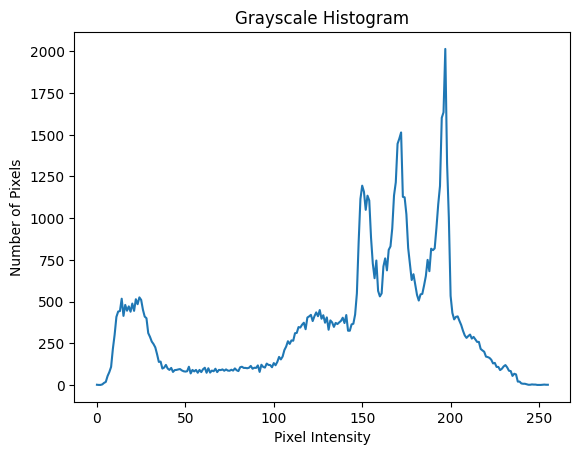

In [ ]:
hist = cv2.calcHist(
    [gray],#using main image
    [0],
    None,
    [256],
    [0, 256]
)

plt.plot(hist)
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")
plt.show()

Histogram Equalization

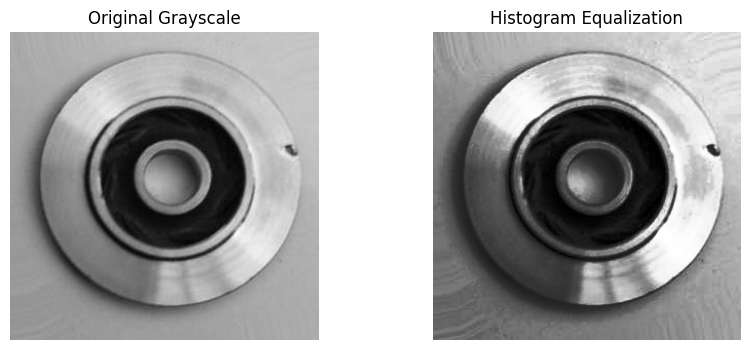

In [ ]:
equalized = cv2.equalizeHist(gray)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(equalized, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")

plt.show()

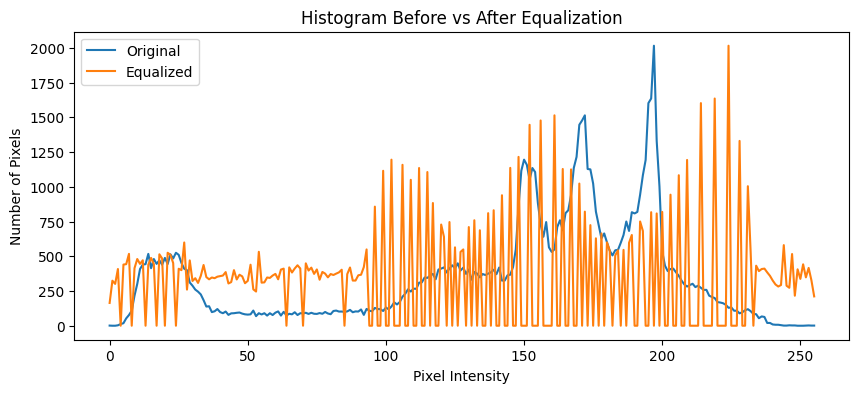

In [ ]:
hist_original = cv2.calcHist(
    [gray], [0], None, [256], [0, 256]
)

hist_equalized = cv2.calcHist(
    [equalized], [0], None, [256], [0, 256]
)

plt.figure(figsize=(10, 4))

plt.plot(hist_original, label="Original")
plt.plot(hist_equalized, label="Equalized")

plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")
plt.title("Histogram Before vs After Equalization")
plt.legend()

plt.show()

### Histogram Equalization

A histogram shows the distribution of pixel intensities in an image.

Histogram Equalization spreads the intensity values over a wider range,
which usually increases the overall contrast of the image.